# HI 21-cm x Gamma-Ray Cross-Correlation Pipeline Validation

This notebook generates all diagnostic and publication figures for the pipeline,
validating against Pinetti, Camera, Fornengo & Regis (2020, arXiv:1911.04989).

**Sections:**
1. HI Model Properties
2. UGRB Mean Intensity Spectrum
3. EBL Opacity & PPPC4DMID Spectra
4. Instrument Noise & Beam Functions
5. Angular Cross-Power Spectra
6. Window Functions
7. SNR Forecast Table
8. DM Exclusion Curves

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 9,
                     'figure.figsize': (8, 5), 'lines.linewidth': 1.5})

from hi_gamma_xcorr import config as cfg, cosmology as cosmo, halo_model as hm
from hi_gamma_xcorr import hi_model as hi, dm_model as dm, astro_sources as astro
from hi_gamma_xcorr import angular_power as ap, noise_model as nm, statistics as stats
from hi_gamma_xcorr import pppc4dmid, ebl

cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.
Pipeline initialized.


In [2]:
# Cache utilities for expensive computations (SNR, exclusion curves)
_cache_dir = os.path.join('..', 'hi_gamma_xcorr', 'plots')
os.makedirs(_cache_dir, exist_ok=True)

def load_cache(name):
    path = os.path.join(_cache_dir, f'{name}.json')
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_cache(name, data):
    with open(os.path.join(_cache_dir, f'{name}.json'), 'w') as f:
        json.dump(data, f, indent=2)

## 1. HI Model Properties

The HI model follows Padmanabhan, Refregier & Amara (2017) with parameters adopted by Pinetti et al. (2020):
$\alpha = 0.176$, $\beta = -0.69$, $v_{c,0} = 101.61$ km/s.

**Known offset:** $\Omega_\mathrm{HI}(z=0) \approx 2 \times 10^{-4}$, about half the ALFALFA value ($\sim 4 \times 10^{-4}$), due to the high $v_{c,0}$ cutoff combined with the SMT mass function normalization.

/home/ikaros/projects/hixugrb/notebooks/../hi_gamma_xcorr/hi_model.py:219: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(integrand, np.log(M_min), np.log(M_max), limit=200, epsrel=1e-5)


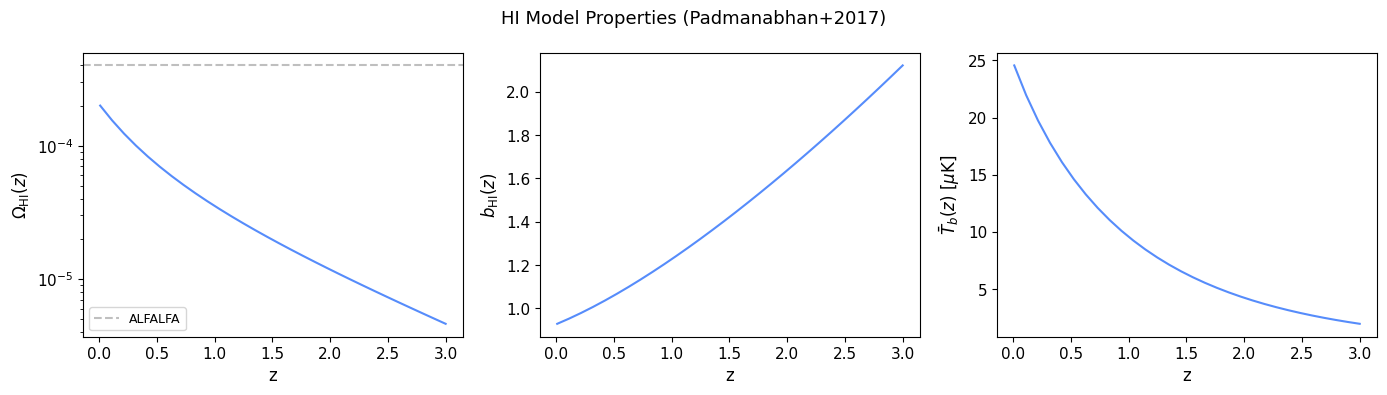

In [3]:
z_arr = np.linspace(0.01, 3.0, 30)
omega = np.array([hi.Omega_HI(z) for z in z_arr])
b_hi = np.array([hi.b_HI(z) for z in z_arr])
Tb = np.array([hi.T_bar_b(z) for z in z_arr])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].semilogy(z_arr, omega)
axes[0].axhline(4e-4, ls='--', color='gray', alpha=0.5, label='ALFALFA')
axes[0].set_ylabel(r'$\Omega_{\rm HI}(z)$'); axes[0].set_xlabel('z'); axes[0].legend()

axes[1].plot(z_arr, b_hi)
axes[1].set_ylabel(r'$b_{\rm HI}(z)$'); axes[1].set_xlabel('z')

axes[2].plot(z_arr, Tb * 1000)
axes[2].set_ylabel(r'$\bar{T}_b(z)$ [$\mu$K]'); axes[2].set_xlabel('z')

fig.suptitle('HI Model Properties (Padmanabhan+2017)', fontsize=13)
fig.tight_layout()

## 2. UGRB Mean Intensity Spectrum

Total unresolved gamma-ray background from four astrophysical source classes (BL Lac, FSRQ, mAGN, SFG). GLFs use LDDE parameterizations from Ajello et al. (2012, 2014) and Di Mauro et al. (2014).

The gray band shows the Ackermann et al. (2015) IGRB measurement. BL Lac currently dominates and is ~10x above the observed IGRB — this is a known normalization issue in the HSP BL Lac A parameter.

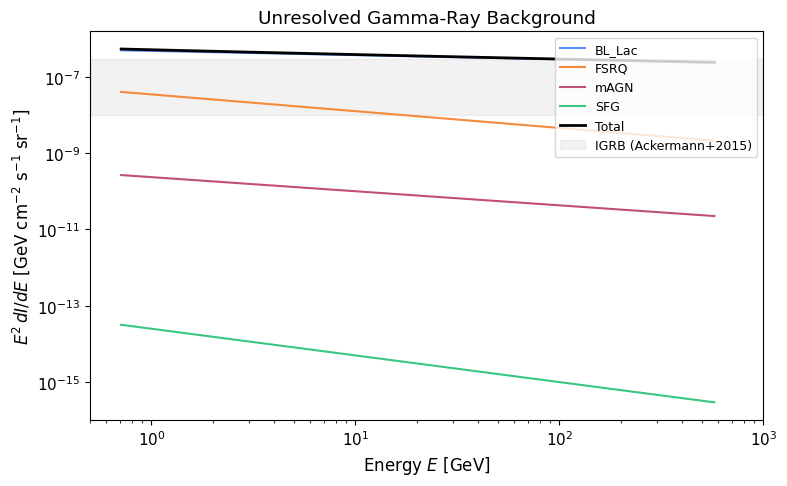

In [4]:
E_arr = cfg.FERMI_E_B
sources = ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3'}

fig, ax = plt.subplots(figsize=(8, 5))
total = np.zeros_like(E_arr)
for src in sources:
    I_arr = np.array([astro.mean_intensity(E, src, z_max=4.0, n_z=20) for E in E_arr])
    ax.loglog(E_arr, E_arr**2 * I_arr, label=src, color=colors[src])
    total += I_arr
ax.loglog(E_arr, E_arr**2 * total, 'k-', lw=2, label='Total')
ax.axhspan(1e-8, 3e-7, alpha=0.1, color='gray', label='IGRB (Ackermann+2015)')
ax.set_xlabel('Energy $E$ [GeV]')
ax.set_ylabel(r'$E^2 \, dI/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
ax.set_title('Unresolved Gamma-Ray Background')
ax.legend(loc='upper right'); ax.set_xlim(0.5, 1000)
fig.tight_layout()

## 3. EBL Opacity & PPPC4DMID Photon Spectra

**Left:** EBL optical depth $\tau(E, z)$ from Dominguez et al. (2011) via `ebltable`. At $E < 10$ GeV the universe is transparent; at $E > 100$ GeV and $z > 0.5$ absorption is significant.

**Right:** PPPC4DMID photon yield $x^2 dN/dx$ for the $b\bar{b}$ channel at three DM masses. Tables from Cirelli et al. (2011).

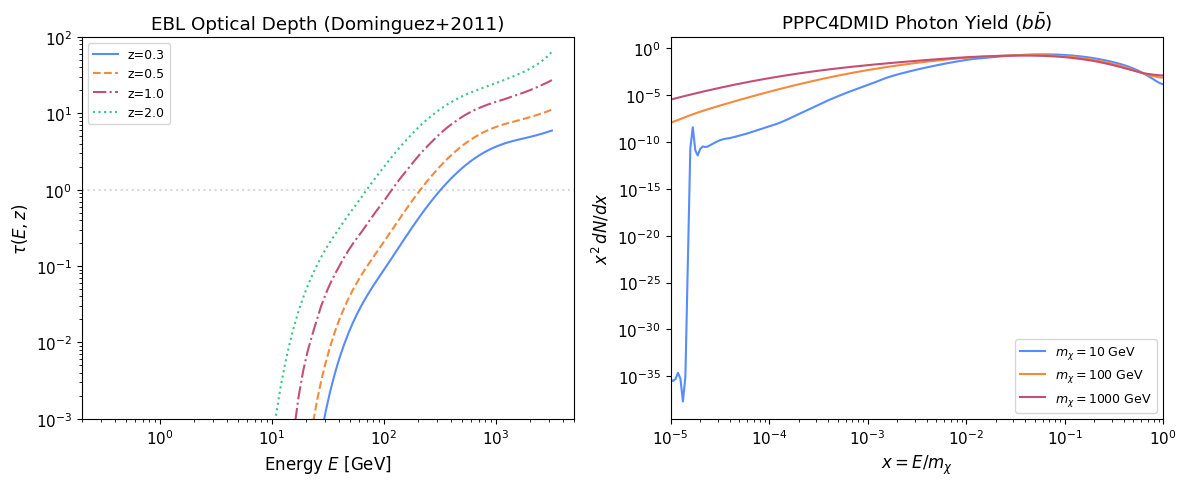

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# EBL opacity
E_ebl = np.logspace(-0.5, 3.5, 100)
for z, ls in [(0.3, '-'), (0.5, '--'), (1.0, '-.'), (2.0, ':')]:
    ax1.semilogy(E_ebl, ebl.tau(E_ebl, z), ls=ls, label=f'z={z}')
ax1.axhline(1.0, ls=':', color='gray', alpha=0.3)
ax1.set_xlabel('Energy $E$ [GeV]'); ax1.set_ylabel(r'$\tau(E, z)$')
ax1.set_title('EBL Optical Depth (Dominguez+2011)')
ax1.set_xscale('log'); ax1.set_ylim(1e-3, 100); ax1.legend()

# PPPC4DMID spectra
x_arr = np.logspace(-5, -0.01, 200)
for m, color in [(10, 'C0'), (100, 'C1'), (1000, 'C2')]:
    dNdx = pppc4dmid.dNdx(x_arr, m, 'bb')
    ax2.loglog(x_arr, x_arr**2 * dNdx, color=color, label=f'$m_\\chi={m}$ GeV')
ax2.set_xlabel('$x = E / m_\\chi$'); ax2.set_ylabel(r'$x^2 \, dN/dx$')
ax2.set_title(r'PPPC4DMID Photon Yield ($b\bar{b}$)'); ax2.legend(); ax2.set_xlim(1e-5, 1)
fig.tight_layout()

## 4. Instrument Noise & Beam Functions

**Left:** Fermi-LAT effective noise $N^\gamma_\ell / (B^\gamma_\ell)^2$ at three energies. PSF improves at higher energy, pushing the noise wall to higher $\ell$.

**Right:** Radio effective noise for MeerKAT, SKA1, SKA2 (dish mode). SKA2's 2000 dishes dramatically reduce the noise floor.

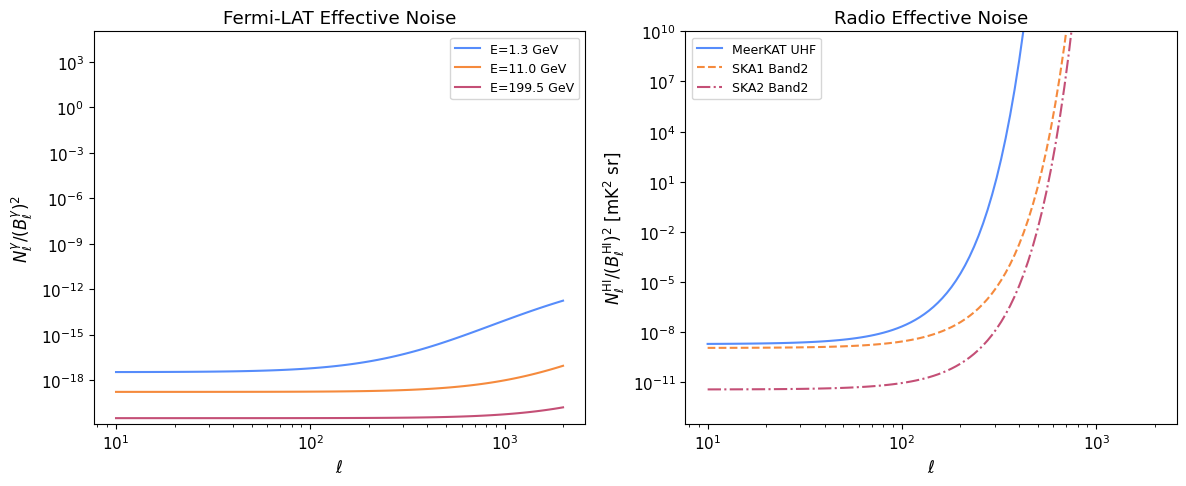

In [6]:
ell_arr = np.logspace(1, 3.3, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ie, color in [(1, 'C0'), (5, 'C1'), (10, 'C2')]:
    E = cfg.FERMI_E_B[ie]; B = nm.beam_fermi(ell_arr, E); N = nm.noise_fermi(ie)
    y = N / np.maximum(B**2, 1e-300)
    y = np.clip(y, 0, 1e10)  # clip infinities for plotting
    ax1.semilogy(ell_arr, y, color=color, label=f'E={E:.1f} GeV')
ax1.set_xlabel(r'$\ell$'); ax1.set_ylabel(r'$N^\gamma_\ell / (B^\gamma_\ell)^2$')
ax1.set_title('Fermi-LAT Effective Noise'); ax1.legend(); ax1.set_xscale('log')
ax1.set_ylim(top=1e5)

for tel, band, color, ls in [('MeerKAT','UHF','C0','-'), ('SKA1','Band2','C1','--'), ('SKA2','Band2','C2','-.')]:
    N_r = nm.noise_radio_combined(ell_arr, tel, band)
    z_mid = 0.5 * (cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_min'] +
                    cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_max'])
    B_r = nm.beam_radio(ell_arr, z_mid, cfg.RADIO_TELESCOPES[tel]['d_dish_m'])
    y = N_r / np.maximum(B_r**2, 1e-300)
    y = np.clip(y, 0, 1e30)
    ax2.semilogy(ell_arr, y, color=color, ls=ls, label=f'{tel} {band}')
ax2.set_xlabel(r'$\ell$'); ax2.set_ylabel(r'$N^{\rm HI}_\ell / (B^{\rm HI}_\ell)^2$ [mK$^2$ sr]')
ax2.set_title('Radio Effective Noise'); ax2.legend(); ax2.set_xscale('log')
ax2.set_ylim(top=1e10)
fig.tight_layout()

## 5. Angular Cross-Power Spectra $C_\ell$

Cross-power spectrum $\ell(\ell+1) C_\ell / 2\pi$ for MeerKAT UHF x Fermi-LAT at $E = 5$ GeV, decomposed by source class. BL Lac dominates the astrophysical signal; the DM contribution (thermal relic, $m_\chi = 100$ GeV, $b\bar{b}$) is ~100x weaker.

This is the core output of the Limber integration engine (`angular_power.py`). Runtime ~30s.

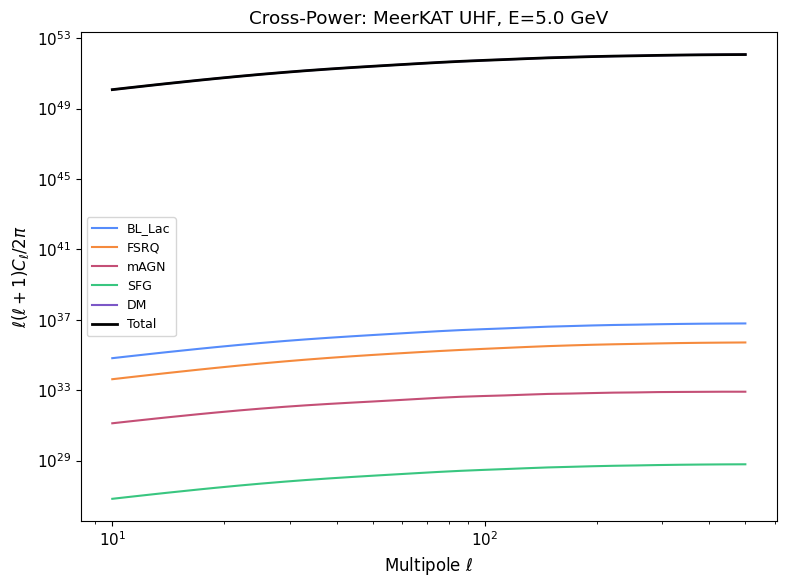

In [7]:
telescope, band, E_GeV = 'MeerKAT', 'UHF', 5.0
tel = cfg.RADIO_TELESCOPES[telescope]
z_min, z_max = tel['bands'][band]['z_min'], tel['bands'][band]['z_max']

ell_cl = np.unique(np.logspace(1, 2.7, 30).astype(int)).astype(float)

result = ap.C_ell_HI_gamma(
    ell_cl, E_GeV, z_min, z_max, telescope, band,
    m_chi_GeV=100.0, sigma_v=cfg.SIGMA_V_THERMAL,
    include_DM=True, n_z=10, n_k_M=15
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3', 'DM': 'C4'}
for key in ['BL_Lac', 'FSRQ', 'mAGN', 'SFG', 'DM']:
    if key in result:
        C = result[key]; nz = np.abs(C) > 0
        if np.any(nz):
            ax.loglog(ell_cl[nz], ell_cl[nz]*(ell_cl[nz]+1)*np.abs(C[nz])/(2*np.pi),
                      label=key, color=colors.get(key))
C_tot = result['total']; nz = np.abs(C_tot) > 0
if np.any(nz):
    ax.loglog(ell_cl[nz], ell_cl[nz]*(ell_cl[nz]+1)*np.abs(C_tot[nz])/(2*np.pi), 'k-', lw=2, label='Total')
ax.set_xlabel(r'Multipole $\ell$'); ax.set_ylabel(r'$\ell(\ell+1) C_\ell / 2\pi$')
ax.set_title(f'Cross-Power: {telescope} {band}, E={E_GeV} GeV'); ax.legend()
fig.tight_layout()

## 6a. Normalized Window Functions — Survey-Independent (Theoretical)

Intrinsic (survey-independent) window functions $W_i(z) / \langle I_i \rangle$ at $E = 5$ GeV. No instrument selection applied:
- **HI:** $\bar{T}_b(z) \times b_\mathrm{HI}(z)$ over the full redshift range (no band selection)
- **Astro sources:** Total emission integrated over $[L_\mathrm{min}, L_\mathrm{max}]$ (no Fermi sensitivity cut)
- **DM:** Intrinsic annihilation kernel ($m_\chi = 100$ GeV, $b\bar{b}$, thermal relic)

In [ ]:
E_ref, m_chi = 5.0, 100.0
z_plot = np.linspace(0.02, 5.0, 100)
dz = z_plot[1] - z_plot[0]
dchi_dz = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_plot])

# --- Survey-independent per-z windows ---
W_hi_intrinsic = np.array([hi.T_bar_b(z) * hi.b_HI(z) for z in z_plot])

astro_srcs = ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']
W_astro_total = {}
for src in astro_srcs:
    W_chi = np.array([astro.W_gamma_astro(E_ref, z, src, unresolved_only=False) for z in z_plot])
    W_astro_total[src] = W_chi * dchi_dz

W_dm_perz = np.array([dm.W_gamma_DM(E_ref, z, m_chi) for z in z_plot]) * dchi_dz

# --- Normalize ---
I_hi = np.sum(W_hi_intrinsic) * dz
I_astro = {src: np.sum(W_astro_total[src]) * dz for src in astro_srcs}
I_dm = np.sum(W_dm_perz) * dz

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

if I_hi > 0:
    ax.plot(z_plot, W_hi_intrinsic / I_hi, color='C4', lw=1.5, label='HI (intrinsic)')
for src, color in [('BL_Lac', 'C0'), ('FSRQ', 'C1'), ('mAGN', 'C2'), ('SFG', 'C3')]:
    if I_astro[src] > 0:
        ax.plot(z_plot, W_astro_total[src] / I_astro[src], color=color, lw=1.5, label=src)
if I_dm > 0:
    ax.plot(z_plot, W_dm_perz / I_dm, color='k', lw=1.5, label=f'DM ($m_\\chi={m_chi:.0f}$ GeV)')

ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'$W_i(z)\;/\;\langle I_i \rangle$', fontsize=13)
ax.set_title(f'Normalized Window Functions — Survey-Independent ($E = {E_ref}$ GeV)', fontsize=13)
ax.legend(fontsize=10); ax.set_xlim(0, 5); ax.set_ylim(bottom=0)
fig.tight_layout()

## 6b. Normalized Window Functions — Survey-Dependent (MeerKAT × Fermi-LAT)

Observable window functions for specific instrument configurations:
- **HI (MeerKAT UHF):** $z = 0.4$–$1.45$ band selection
- **HI (MeerKAT L):** $z = 0.0$–$0.58$ band selection
- **Astro sources:** Unresolved only (Fermi-LAT $F_\mathrm{sens} = 10^{-10}$ cm$^{-2}$ s$^{-1}$ threshold applied)
- **DM:** Same as theoretical (no survey dependence)

In [ ]:
# --- Survey-dependent per-z windows ---
z_plot2 = np.linspace(0.02, 4.0, 80)
dz2 = z_plot2[1] - z_plot2[0]
dchi_dz2 = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_plot2])

# HI with MeerKAT band selections
bands = [('UHF', 0.4, 1.45, '-'), ('L', 0.0, 0.58, '--')]
W_hi_bands = {}
for name, zlo, zhi, _ in bands:
    W_chi = np.array([hi.W_HI(z, zlo, zhi) for z in z_plot2])
    W_hi_bands[name] = W_chi * dchi_dz2

# Astro: unresolved only (Fermi threshold)
W_astro_unresolved = {}
for src in astro_srcs:
    W_chi = np.array([astro.W_gamma_astro(E_ref, z, src, unresolved_only=True) for z in z_plot2])
    W_astro_unresolved[src] = W_chi * dchi_dz2

# DM
W_dm2 = np.array([dm.W_gamma_DM(E_ref, z, m_chi) for z in z_plot2]) * dchi_dz2

# --- Normalize ---
I_hi_bands = {name: np.sum(W_hi_bands[name]) * dz2 for name, *_ in bands}
I_astro2 = {src: np.sum(W_astro_unresolved[src]) * dz2 for src in astro_srcs}
I_dm2 = np.sum(W_dm2) * dz2

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

for name, zlo, zhi, ls in bands:
    I = I_hi_bands[name]
    if I > 0:
        ax.plot(z_plot2, W_hi_bands[name] / I, color='C4', ls=ls, lw=1.5,
                label=f'HI (MeerKAT {name}, z={zlo}–{zhi})')

for src, color in [('BL_Lac', 'C0'), ('FSRQ', 'C1'), ('mAGN', 'C2'), ('SFG', 'C3')]:
    I = I_astro2[src]
    if I > 0:
        ax.plot(z_plot2, W_astro_unresolved[src] / I, color=color, lw=1.5,
                label=f'{src} (Fermi)')

if I_dm2 > 0:
    ax.plot(z_plot2, W_dm2 / I_dm2, color='k', lw=1.5,
            label=f'DM ($m_\\chi={m_chi:.0f}$ GeV)')

ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'$W_i(z)\;/\;\langle I_i \rangle$', fontsize=13)
ax.set_title(f'Normalized Window Functions — MeerKAT × Fermi-LAT ($E = {E_ref}$ GeV)', fontsize=13)
ax.legend(fontsize=9, loc='upper right'); ax.set_xlim(0, 4); ax.set_ylim(bottom=0)
fig.tight_layout()

## 7. SNR Forecast Table (Pinetti et al. Table 4)

Signal-to-noise ratio for detecting the HI x gamma-ray cross-correlation, compared to Pinetti et al. (2020) targets (red stars). Uses all 12 Fermi energy bins summed over $\ell = 10$-$500$.

**Key result:** SKA1 Band2 matches the Pinetti target exactly (5.75 vs 5.7).

This cell loads from cache if available (~2 min to recompute).

In [ ]:
configs = [
    ('MeerKAT', 'UHF', 3.7), ('MeerKAT', 'L', 2.0),
    ('SKA1', 'Band1', None), ('SKA1', 'Band2', 5.7),
    ('SKA2', 'Band1', 8.2), ('SKA2', 'Band2', None),
]

snr_data = load_cache('snr_results')
if snr_data is None:
    snr_data = {}
    for tel, bnd, target in configs:
        key = f'{tel}_{bnd}'
        print(f'  Computing SNR for {tel} {bnd}...')
        snr = stats.compute_SNR(tel, bnd, ell_min=10, ell_max=500, n_ell=25, n_z=10, n_M=15)
        snr_data[key] = {'snr': snr, 'target': target}
    save_cache('snr_results', snr_data)

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f'{t}\n{b}' for t, b, _ in configs]
snr_vals = [snr_data[f'{t}_{b}']['snr'] for t, b, _ in configs]
targets = [tgt for _, _, tgt in configs]

x = np.arange(len(labels))
ax.bar(x, snr_vals, color='steelblue', alpha=0.8, label='This work')
for i, t in enumerate(targets):
    if t is not None: ax.plot(i, t, 'r*', ms=12, zorder=5)
ax.scatter([], [], c='r', marker='*', s=100, label='Pinetti+2020')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Signal-to-Noise Ratio')
ax.set_title('SNR Forecasts: HI x Gamma-Ray Cross-Correlation')
ax.legend(); ax.axhline(3.0, ls=':', color='gray', alpha=0.3)
fig.tight_layout()

## 8. DM Exclusion Curves

95% CL upper limits on the annihilation cross-section $\langle\sigma v\rangle$ as a function of DM mass $m_\chi$, for the $b\bar{b}$ channel. The dashed line marks the thermal relic value $3 \times 10^{-26}$ cm$^3$/s.

SKA2 is more constraining than SKA1 due to its larger dish count. The limits are ~3-10x above thermal relic, consistent with Pinetti et al. who show thermal sensitivity requires SKA2 x Fermissimo.

Loads from cache if available (~90s to recompute per telescope).

In [ ]:
exc_data = load_cache('exclusion_results')
if exc_data is None:
    exc_data = {}
    m_arr = np.array([30., 100., 300., 1000., 3000.])
    for tel, bnd in [('SKA1', 'Band2'), ('SKA2', 'Band2')]:
        key = f'{tel}_{bnd}'
        print(f'  Computing exclusion for {tel} {bnd}...')
        m, sv = stats.exclusion_curve(tel, bnd, channel='bb', CL='95',
                                       m_chi_arr=m_arr, n_ell=10, n_z=6, n_M=8)
        exc_data[key] = {'m_chi': m.tolist(), 'sigma_v': sv.tolist()}
    save_cache('exclusion_results', exc_data)

fig, ax = plt.subplots(figsize=(8, 6))
labels_exc = {'SKA1_Band2': 'SKA1 Band2', 'SKA2_Band2': 'SKA2 Band2'}
colors_exc = {'SKA1_Band2': 'C1', 'SKA2_Band2': 'C2'}
for key in exc_data:
    m = np.array(exc_data[key]['m_chi']); sv = np.array(exc_data[key]['sigma_v'])
    valid = np.isfinite(sv) & (sv > 0)
    if np.any(valid):
        ax.loglog(m[valid], sv[valid], color=colors_exc.get(key, 'gray'), label=labels_exc.get(key, key))
ax.axhline(cfg.SIGMA_V_THERMAL, ls='--', color='k', alpha=0.5, label=r'Thermal relic $\langle\sigma v\rangle$')
ax.set_xlabel(r'$m_\chi$ [GeV]'); ax.set_ylabel(r'$\langle\sigma v\rangle$ [cm$^3$/s]')
ax.set_title(r'95% CL Upper Limits ($b\bar{b}$ channel)')
ax.legend(); ax.set_xlim(10, 5000); ax.set_ylim(1e-28, 1e-22)
fig.tight_layout()